# LLMs as Token-Level MDPs

You already know PPO in the classical setting. The new thing is learning to look at **autoregressive generation itself as an RL trajectory**.

> **Note:** Papers will appear exactly where they become useful, not dumped as a reading list upfront. Some lessons may have no paper if reading one there would add noise.

# Module 3 — Lesson 3.1: LLMs as Token-Level MDPs

You already know PPO in the classical setting. The new thing is learning to look at **autoregressive generation itself as an RL trajectory**.

Your existing work already treats generation as repeated next-token sampling from a decoder LM, so we're building directly on that rather than revisiting Transformer internals.

---

## 1. The Mapping

**Classical RL:**

$$s_t \rightarrow a_t \rightarrow r_t \rightarrow s_{t+1}$$

**For an LLM:**

$$s_t = (x, y_{<t})$$

$$a_t = y_t$$

Where:
- $x$ = prompt
- $y_{<t}$ = tokens already generated
- $y_t$ = next generated token

**Step-by-step Execution:**

```text
Prompt:
"2 + 2 ="

State s0:
"2 + 2 ="

Action a0:
" 4"

State s1:
"2 + 2 = 4"

Action a1:
"<EOS>"
```

The **policy** is simply:

$$\pi_\theta(a_t | s_t) = P_\theta(y_t | x, y_{<t})$$

That's just the probability distribution from your LM head.

Nothing magical happened — your language model was already a stochastic policy.

---

## 2. What is an Episode?

Suppose:

```text
Prompt:
"What is 15 * 3?"

Generation:
"The answer is 45."
```

Tokenized conceptually:

```text
Prompt tokens:
[What] [is] [15] [*] [3] [?]

Generated tokens:
[The] [answer] [is] [45] [.] [EOS]
```

The RL trajectory is:

```text
s0 → "The"
s1 → "answer"
s2 → "is"
s3 → "45"
s4 → "."
s5 → EOS
```

Therefore, one response is normally one episode:

$$\tau = (s_0, a_0, s_1, a_1, \dots, s_T, a_T)$$

For **single-turn RLHF**, that's enough. Module 4 will break this assumption when tools and multiple conversation turns enter the environment.

---

## 3. The Critical Distinction: Prompt Tokens are NOT Actions

Consider:

```text
[USER]      What is 15 * 3?
[ASSISTANT] The answer is 45.
```

The model did **not** choose:

```text
What
is
15
*
3
?
```

Those came from the environment/user.

It **only** chose:

```text
The
answer
is
45
.
EOS
```

Therefore PPO must **only** optimize the generated region. We need an **action mask**:

```text
tokens:  [What] [is] [15] [*] [3] [?] [The] [answer] [is] [45] [.] [EOS]
mask:       0     0    0   0   0   0    1      1      1    1    1    1
```

This tiny-looking idea is fundamental. If you accidentally calculate policy loss on prompt tokens, you're optimizing actions the policy never took.

---

## 4. Three Masks You Should Stop Confusing

We'll encounter several masks:

### A. Attention Mask

Controls which real tokens exist versus padding.

```text
1 1 1 1 1 1 1 1 0 0
```

Usually referenced as `attention_mask`.

---

### B. Causal Mask

Inside attention: token $t$ cannot see future tokens.

```text
token t cannot see future tokens
```

You've already implemented this concept in causal self-attention. Usually Qwen handles this internally.

---

### C. Response / Action Mask

Our RL-specific mask:

```text
prompt   = 0
response = 1
padding  = 0
```

**Example:**

```text
Prompt      Response       Padding
0 0 0 0     1 1 1 1       0 0 0
```

This determines which tokens participate in:
- policy loss
- value loss
- KL divergence
- advantages
- returns
- entropy statistics

depending on the algorithm. This mask becomes **extremely important** later.

---

## 5. Where Does Reward Live?

This is where LLM RL starts becoming interesting. Suppose Qwen generates: `"The answer is 45."` and our verifier gives $R = 1$.

The simplest representation is **terminal reward**:

```text
The       0
answer    0
is        0
45        0
.         0
EOS       +1
```

So:

$$r_t = 0 \qquad \text{for } t < T$$

and:

$$r_T = R(x, y)$$

This creates a **credit-assignment problem**. Every token helped create the successful answer, yet the reward appears only at the end.

That's one reason we later need:
- critic
- returns
- GAE (Generalized Advantage Estimation)
- advantages

But **do not jump there yet**. First we need correct trajectories.

---

## 6. RLHF Introduces Another Token Reward

Later we'll add KL regularization. Then the reward may look approximately like:

$$r_t^{\text{KL}} = -\beta \left( \log\pi_\theta(a_t|s_t) - \log\pi_{\text{ref}}(a_t|s_t) \right)$$

for every generated token. And at the final token:

$$r_T = r_T^{\text{KL}} + R_{\text{task}}$$

So eventually:

```text
token 1       KL penalty
token 2       KL penalty
token 3       KL penalty
...
final token   KL penalty + RM/verifier reward
```

Don't implement this today. I'm showing it so the trajectory format we build **won't need to be redesigned later**.

---

## 7. What Exactly Do We Store?

This is today's main engineering goal. For every rollout:

```python
Trajectory(
    prompt_ids,
    response_ids,
    input_ids,
    attention_mask,
    action_mask,
)
```

Soon this becomes:

```python
Trajectory(
    prompt_ids,
    response_ids,
    input_ids,
    attention_mask,
    action_mask,

    old_logprobs,
    ref_logprobs,

    rewards,
    values,
    advantages,
    returns,

    metadata,
)
```

But **Lesson 3.1 only owns the first five**.

---

## 8. Shape Discipline

Suppose:

```text
batch_size = B
total_sequence_length = T
```

Then:

```text
input_ids       [B, T]
attention_mask  [B, T]
action_mask     [B, T]
```

Later:

```text
old_logprobs    [B, T-1]
ref_logprobs    [B, T-1]
values          [B, T-1]
rewards         [B, T-1]
advantages      [B, T-1]
returns         [B, T-1]
```

Why often $T-1$? Because:

```text
token at position t  ──predicts──>  token at position t+1
```

For logits:
```python
logits[:, :-1]
```

correspond to targets:
```python
input_ids[:, 1:]
```

This off-by-one alignment bug is one of the easiest ways to silently screw up RLHF training. We'll explicitly test it next lesson.

---

## 9. Qwen Rollout Pipeline

For our Qwen 1.5B setup:

```text
Prompt
  │
  ▼
Tokenizer
  │
  ▼
prompt_ids
  │
  ▼
Qwen.generate()
  │
  ▼
prompt + response IDs
  │
  ├── identify generated span
  │
  ├── construct action mask
  │
  └── decode response
  │
  ▼
Trajectory
```

### Notice:

#### `generate()` is NOT the Trainer

It's our **environment interaction / rollout engine**. That's an important architectural separation.

Later:

```text
ROLL OUT
Qwen → trajectories

OPTIMIZE
trajectories → PPO/GRPO → parameter update
```

Don't mix those two pieces.

---

### Shift in Paradigm

**Before (LLM Generation):**

```text
prompt  ──>  model.generate()  ──>  text
```

**Now (RL Rollout):**

```text
initial state
     │
     ▼
   policy
     │
     ▼
 action/token
     │
     ▼
new state/prefix
     │
     ▼
   policy
     │
     ▼
 action/token
     │
     ▼
    ...
     │
     ▼
terminal response
```

And simultaneously:

$$\text{generated text} = \text{RL trajectory}$$

That single reinterpretation unlocks everything we're about to do.

## Qwen Rollout Collector

In [2]:
import time
import random
from dataclasses import dataclass
from typing import Optional, List

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())
print("Device          :", device)

if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))
    print(
        "GPU VRAM       :",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB",
    )

c:\WHATEVERELSE\GeekStuff\conda\envs\pygpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version : 2.7.1+cu118
CUDA available  : True
Device          : cuda
GPU             : NVIDIA GeForce RTX 3050 Laptop GPU
GPU VRAM       : 4.0 GB


> **Important Design Principle:**
> 
> Rollout generation = inference.
> 
> So for now:
> - No optimizer
> - No gradients
> - No value head
> - No PPO
> - No GRPO
> 
> We are building the trajectory-producing side first.

In [3]:
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

if torch.cuda.is_available():
    if torch.cuda.is_bf16_supported():
        model_dtype = torch.bfloat16
    else:
        model_dtype = torch.float16
else:
    model_dtype = torch.float32

print("Loading:", MODEL_NAME)
print("dtype  :", model_dtype)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=model_dtype,
)

model = model.to(device)
model.eval()

print("\nModel loaded.")
print("Model device:", next(model.parameters()).device)

num_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters    : {num_params / 1e9:.3f} B")
print(f"Trainable parameters: {trainable_params / 1e9:.3f} B")

Loading: Qwen/Qwen2.5-1.5B-Instruct
dtype  : torch.bfloat16


c:\WHATEVERELSE\GeekStuff\conda\envs\pygpu\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ujwal\.cache\huggingface\hub\models--Qwen--Qwen2.5-1.5B-Instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
`torch_dtype` is deprecated! Use `dtype` instead!



Model loaded.
Model device: cuda:0
Total parameters    : 1.544 B
Trainable parameters: 1.544 B


In [4]:
messages = [
    {
        "role": "user",
        "content": "What is 15 multiplied by 3?"
    }
]

formatted_prompt = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

print("=== RAW USER MESSAGE ===")
print(messages[0]["content"])

print("\n=== ACTUAL TEXT GIVEN TO QWEN ===")
print(repr(formatted_prompt))

print("\n=== HUMAN-READABLE VERSION ===")
print(formatted_prompt)

=== RAW USER MESSAGE ===
What is 15 multiplied by 3?

=== ACTUAL TEXT GIVEN TO QWEN ===
'<|im_start|>system\nYou are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>\n<|im_start|>user\nWhat is 15 multiplied by 3?<|im_end|>\n<|im_start|>assistant\n'

=== HUMAN-READABLE VERSION ===
<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
What is 15 multiplied by 3?<|im_end|>
<|im_start|>assistant



In [5]:
prompt_encoding = tokenizer(
    formatted_prompt,
    return_tensors="pt",
    add_special_tokens=False,
)

prompt_ids = prompt_encoding["input_ids"].to(device)
prompt_attention_mask = prompt_encoding["attention_mask"].to(device)

print("input_ids shape      :", prompt_ids.shape)
print("attention_mask shape :", prompt_attention_mask.shape)

print("\nPrompt token count:", prompt_ids.shape[1])

input_ids shape      : torch.Size([1, 39])
attention_mask shape : torch.Size([1, 39])

Prompt token count: 39


In [6]:
prompt_tokens = []

for position, token_id in enumerate(prompt_ids[0].tolist()):
    token_text = tokenizer.decode(
        [token_id],
        skip_special_tokens=False
    )

    prompt_tokens.append({
        "position": position,
        "token_id": token_id,
        "token": repr(token_text),
        "source": "ENVIRONMENT",
        "action": False,
    })

prompt_df = pd.DataFrame(prompt_tokens)

prompt_df

,position,token_id,token,source,action
0,0,151644,'<|im_start|>',ENVIRONMENT,False
1,1,8948,'system',ENVIRONMENT,False
2,2,198,'\n',ENVIRONMENT,False
3,3,2610,'You',ENVIRONMENT,False
4,4,525,' are',ENVIRONMENT,False
5,5,1207,' Q',ENVIRONMENT,False
6,6,16948,'wen',ENVIRONMENT,False
7,7,11,"','",ENVIRONMENT,False
8,8,3465,' created',ENVIRONMENT,False
9,9,553,' by',ENVIRONMENT,False


In [7]:
MAX_NEW_TOKENS = 64

with torch.inference_mode():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    generated_ids = model.generate(
        input_ids=prompt_ids,
        attention_mask=prompt_attention_mask,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=True,
        temperature=0.8,
        top_p=0.95,
        pad_token_id=tokenizer.eos_token_id,
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    generation_time = time.perf_counter() - start_time

print("Generated tensor shape:", generated_ids.shape)
print(f"Generation time: {generation_time:.3f} seconds")

Generated tensor shape: torch.Size([1, 54])
Generation time: 6.011 seconds


In [8]:
prompt_length = prompt_ids.shape[1]

response_ids = generated_ids[:, prompt_length:]

response_length = response_ids.shape[1]

response_text = tokenizer.decode(
    response_ids[0],
    skip_special_tokens=True
)

print("Prompt length   :", prompt_length)
print("Response length :", response_length)

print("\n=== RESPONSE ===")
print(response_text)

Prompt length   : 39
Response length : 15

=== RESPONSE ===
The product of 15 and 3 is 45.


### Conceptually:

```text
prompt                  response
  ↓                        ↓
0 0 0 0 0 0 0 0 0      1 1 1 1 1 1 ...
```

In [9]:
action_mask = torch.zeros_like(generated_ids, dtype=torch.bool)

action_mask[:, prompt_length:] = True

print("generated_ids shape :", generated_ids.shape)
print("action_mask shape   :", action_mask.shape)

print("\nAction tokens:", action_mask.sum().item())
print("Expected     :", response_length)

assert action_mask.sum().item() == response_length

print("\nMask sanity check passed.")

generated_ids shape : torch.Size([1, 54])
action_mask shape   : torch.Size([1, 54])

Action tokens: 15
Expected     : 15

Mask sanity check passed.


In [10]:
trajectory_rows = []

for position, (token_id, is_action) in enumerate(
    zip(
        generated_ids[0].tolist(),
        action_mask[0].tolist()
    )
):
    token_text = tokenizer.decode(
        [token_id],
        skip_special_tokens=False
    )

    trajectory_rows.append({
        "position": position,
        "token_id": token_id,
        "token": repr(token_text),
        "source": "POLICY" if is_action else "ENVIRONMENT",
        "action_mask": int(is_action),
    })

trajectory_df = pd.DataFrame(trajectory_rows)

trajectory_df

,position,token_id,token,source,action_mask
0,0,151644,'<|im_start|>',ENVIRONMENT,0
1,1,8948,'system',ENVIRONMENT,0
2,2,198,'\n',ENVIRONMENT,0
3,3,2610,'You',ENVIRONMENT,0
4,4,525,' are',ENVIRONMENT,0
5,5,1207,' Q',ENVIRONMENT,0
6,6,16948,'wen',ENVIRONMENT,0
7,7,11,"','",ENVIRONMENT,0
8,8,3465,' created',ENVIRONMENT,0
9,9,553,' by',ENVIRONMENT,0


> When we later add `logprobs`, `advantages`, `rewards`, and `KL`, we'll extend essentially this same inspection table.

In [11]:
print("=" * 90)
print(f"{'POS':<6} {'MASK':<6} {'SOURCE':<14} TOKEN")
print("=" * 90)

for row in trajectory_rows:
    print(
        f"{row['position']:<6} "
        f"{row['action_mask']:<6} "
        f"{row['source']:<14} "
        f"{row['token']}"
    )

POS    MASK   SOURCE         TOKEN
0      0      ENVIRONMENT    '<|im_start|>'
1      0      ENVIRONMENT    'system'
2      0      ENVIRONMENT    '\n'
3      0      ENVIRONMENT    'You'
4      0      ENVIRONMENT    ' are'
5      0      ENVIRONMENT    ' Q'
6      0      ENVIRONMENT    'wen'
7      0      ENVIRONMENT    ','
8      0      ENVIRONMENT    ' created'
9      0      ENVIRONMENT    ' by'
10     0      ENVIRONMENT    ' Alibaba'
11     0      ENVIRONMENT    ' Cloud'
12     0      ENVIRONMENT    '.'
13     0      ENVIRONMENT    ' You'
14     0      ENVIRONMENT    ' are'
15     0      ENVIRONMENT    ' a'
16     0      ENVIRONMENT    ' helpful'
17     0      ENVIRONMENT    ' assistant'
18     0      ENVIRONMENT    '.'
19     0      ENVIRONMENT    '<|im_end|>'
20     0      ENVIRONMENT    '\n'
21     0      ENVIRONMENT    '<|im_start|>'
22     0      ENVIRONMENT    'user'
23     0      ENVIRONMENT    '\n'
24     0      ENVIRONMENT    'What'
25     0      ENVIRONMENT    ' is'
26     0

### Attention Mask vs. Action Mask

Right now there is no padding, so our full attention mask is simply all ones.

*Cell: Build full attention mask*

In [12]:
full_attention_mask = torch.ones_like(
    generated_ids,
    dtype=torch.long
)

comparison_df = pd.DataFrame({
    "position": list(range(generated_ids.shape[1])),
    "token": [
        repr(
            tokenizer.decode(
                [token_id],
                skip_special_tokens=False
            )
        )
        for token_id in generated_ids[0].tolist()
    ],
    "attention_mask": full_attention_mask[0].cpu().tolist(),
    "action_mask": action_mask[0].int().cpu().tolist(),
})

comparison_df

,position,token,attention_mask,action_mask
0,0,'<|im_start|>',1,0
1,1,'system',1,0
2,2,'\n',1,0
3,3,'You',1,0
4,4,' are',1,0
5,5,' Q',1,0
6,6,'wen',1,0
7,7,"','",1,0
8,8,' created',1,0
9,9,' by',1,0


### Why Are They Different?

Because the prompt is:
- Visible to the model
- Part of the state

but:
- **Not an action**
- **Not something PPO/GRPO should optimize as an action**

So:

$$\text{attention mask} \neq \text{action mask}$$

In [13]:
print("EOS token     :", repr(tokenizer.eos_token))
print("EOS token ID  :", tokenizer.eos_token_id)

print("PAD token     :", repr(tokenizer.pad_token))
print("PAD token ID  :", tokenizer.pad_token_id)

print("\nSpecial tokens map:")
print(tokenizer.special_tokens_map)

EOS token     : '<|im_end|>'
EOS token ID  : 151645
PAD token     : '<|endoftext|>'
PAD token ID  : 151643

Special tokens map:
{'eos_token': '<|im_end|>', 'pad_token': '<|endoftext|>', 'additional_special_tokens': ['<|im_start|>', '<|im_end|>', '<|object_ref_start|>', '<|object_ref_end|>', '<|box_start|>', '<|box_end|>', '<|quad_start|>', '<|quad_end|>', '<|vision_start|>', '<|vision_end|>', '<|vision_pad|>', '<|image_pad|>', '<|video_pad|>']}


In [14]:
eos_token_id = tokenizer.eos_token_id

response_token_list = response_ids[0].tolist()

eos_positions = [
    i
    for i, token_id in enumerate(response_token_list)
    if token_id == eos_token_id
]

eos_reached = len(eos_positions) > 0

if eos_reached:
    first_eos_position = eos_positions[0]
else:
    first_eos_position = None

print("EOS reached        :", eos_reached)
print("First EOS position :", first_eos_position)
print("Response tokens    :", response_length)

EOS reached        : True
First EOS position : 14
Response tokens    : 15


In [15]:
hit_max_new_tokens = (
    response_length >= MAX_NEW_TOKENS
    and not eos_reached
)

print("EOS reached        :", eos_reached)
print("Hit max_new_tokens :", hit_max_new_tokens)

if eos_reached:
    print("Termination reason : EOS")
elif hit_max_new_tokens:
    print("Termination reason : MAX_NEW_TOKENS / TRUNCATED")
else:
    print("Termination reason : OTHER")

EOS reached        : True
Hit max_new_tokens : False
Termination reason : EOS


### Define Our Actual Trajectory Object

Now that every field has a clear meaning, let's create the trajectory object.

In [16]:
@dataclass
class LLMTrajectory:
    # Text
    prompt_text: str
    response_text: str

    # Core tensors
    input_ids: torch.Tensor
    attention_mask: torch.Tensor
    action_mask: torch.Tensor

    # Sequence metadata
    prompt_length: int
    response_length: int

    # Termination metadata
    eos_reached: bool
    truncated: bool

    # Performance metadata
    generation_time: float
    tokens_per_second: float

    def summary(self):
        return {
            "prompt_length": self.prompt_length,
            "response_length": self.response_length,
            "eos_reached": self.eos_reached,
            "truncated": self.truncated,
            "generation_time_sec": self.generation_time,
            "tokens_per_second": self.tokens_per_second,
        }

> **Notice what is deliberately absent:**
> 
> - `old_logprobs`
> - `reference_logprobs`
> - `reward`
> - `value`
> - `advantage`
> - `return`
> 
> Those don't belong to this part of the codebase yet.

In [17]:
@torch.inference_mode()
def collect_rollout(
    model,
    tokenizer,
    prompt: str,
    max_new_tokens: int = 64,
    temperature: float = 0.8,
    top_p: float = 0.95,
):
    """
    Generate one single-turn LLM RL trajectory.

    Returns:
        LLMTrajectory
    """

    # ---------------------------------------------------------
    # 1. Convert user prompt into Qwen chat format
    # ---------------------------------------------------------
    messages = [
        {
            "role": "user",
            "content": prompt
        }
    ]

    formatted_prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    # ---------------------------------------------------------
    # 2. Tokenize the environment/context
    # ---------------------------------------------------------
    encoded = tokenizer(
        formatted_prompt,
        return_tensors="pt",
        add_special_tokens=False,
    )

    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)

    prompt_length = input_ids.shape[1]

    # ---------------------------------------------------------
    # 3. Generate policy actions
    # ---------------------------------------------------------
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    generated_ids = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=temperature,
        top_p=top_p,
        pad_token_id=tokenizer.eos_token_id,
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    generation_time = time.perf_counter() - start_time

    # ---------------------------------------------------------
    # 4. Extract only policy-generated actions
    # ---------------------------------------------------------
    response_ids = generated_ids[:, prompt_length:]

    response_length = response_ids.shape[1]

    # ---------------------------------------------------------
    # 5. Action mask
    # ---------------------------------------------------------
    action_mask = torch.zeros_like(
        generated_ids,
        dtype=torch.bool,
    )

    action_mask[:, prompt_length:] = True

    # ---------------------------------------------------------
    # 6. Full attention mask
    #
    # Single unpadded trajectory => every token exists.
    # Batched variable-length trajectories come later.
    # ---------------------------------------------------------
    full_attention_mask = torch.ones_like(
        generated_ids,
        dtype=torch.long,
    )

    # ---------------------------------------------------------
    # 7. Decode response
    # ---------------------------------------------------------
    response_text = tokenizer.decode(
        response_ids[0],
        skip_special_tokens=True,
    )

    # ---------------------------------------------------------
    # 8. Termination metadata
    # ---------------------------------------------------------
    response_token_list = response_ids[0].tolist()

    eos_reached = tokenizer.eos_token_id in response_token_list

    truncated = (
        response_length >= max_new_tokens
        and not eos_reached
    )

    # ---------------------------------------------------------
    # 9. Throughput
    # ---------------------------------------------------------
    tokens_per_second = (
        response_length / generation_time
        if generation_time > 0
        else float("inf")
    )

    trajectory = LLMTrajectory(
        prompt_text=prompt,
        response_text=response_text,

        input_ids=generated_ids.detach().cpu(),
        attention_mask=full_attention_mask.detach().cpu(),
        action_mask=action_mask.detach().cpu(),

        prompt_length=prompt_length,
        response_length=response_length,

        eos_reached=eos_reached,
        truncated=truncated,

        generation_time=generation_time,
        tokens_per_second=tokens_per_second,
    )

    return trajectory

In [18]:
trajectory = collect_rollout(
    model=model,
    tokenizer=tokenizer,
    prompt="What is 17 multiplied by 6?",
    max_new_tokens=64,
)

print("=== RESPONSE ===")
print(trajectory.response_text)

print("\n=== TRAJECTORY SUMMARY ===")
print(trajectory.summary())

=== RESPONSE ===
To calculate \(17 \times 6\), you can use the multiplication method or recognize it as repeated addition.

**Using Multiplication:**
\[17 \times 6 = 17 + 17 + 17 + 17 + 17 + 17\]

Adding

=== TRAJECTORY SUMMARY ===
{'prompt_length': 39, 'response_length': 64, 'eos_reached': False, 'truncated': True, 'generation_time_sec': 11.24788839998655, 'tokens_per_second': 5.689956881157936}


### Reusable Trajectory Inspector

In [19]:
def inspect_trajectory(
    trajectory: LLMTrajectory,
    tokenizer,
) -> pd.DataFrame:

    ids = trajectory.input_ids[0]
    attention = trajectory.attention_mask[0]
    actions = trajectory.action_mask[0]

    rows = []

    for position in range(len(ids)):
        token_id = int(ids[position])

        token_text = tokenizer.decode(
            [token_id],
            skip_special_tokens=False,
        )

        rows.append({
            "position": position,
            "token_id": token_id,
            "token": repr(token_text),
            "attention_mask": int(attention[position]),
            "action_mask": int(actions[position]),
            "source": (
                "POLICY"
                if bool(actions[position])
                else "ENVIRONMENT"
            ),
        })

    return pd.DataFrame(rows)

In [20]:
inspect_df = inspect_trajectory(
    trajectory,
    tokenizer
)

inspect_df

,position,token_id,token,attention_mask,action_mask,source
0,0,151644,'<|im_start|>',1,0,ENVIRONMENT
1,1,8948,'system',1,0,ENVIRONMENT
2,2,198,'\n',1,0,ENVIRONMENT
3,3,2610,'You',1,0,ENVIRONMENT
4,4,525,' are',1,0,ENVIRONMENT
...,...,...,...,...,...,...
98,98,16,'1',1,1,POLICY
99,99,22,'7',1,1,POLICY
100,100,59,'\\',1,1,POLICY
101,101,2533,']\n\n',1,1,POLICY


In [21]:
def validate_trajectory(
    trajectory: LLMTrajectory,
):
    input_ids = trajectory.input_ids
    attention_mask = trajectory.attention_mask
    action_mask = trajectory.action_mask

    # Shape consistency
    assert input_ids.shape == attention_mask.shape
    assert input_ids.shape == action_mask.shape

    # We currently handle one rollout
    assert input_ids.shape[0] == 1

    total_length = input_ids.shape[1]

    # Sequence accounting
    assert (
        trajectory.prompt_length
        + trajectory.response_length
        == total_length
    )

    # Number of actions should equal generated tokens
    assert (
        action_mask.sum().item()
        == trajectory.response_length
    )

    # Prompt tokens must not be actions
    assert not action_mask[
        0,
        :trajectory.prompt_length
    ].any()

    # Response tokens must all be actions
    assert action_mask[
        0,
        trajectory.prompt_length:
    ].all()

    # All actual tokens exist
    assert attention_mask.all()

    print("All trajectory checks passed.")

validate_trajectory(trajectory)

All trajectory checks passed.


### Understand Next-Token Alignment Now

We're not calculating logprobs yet, but I want you to physically see the alignment that Lesson 3.3 will use.

Suppose:

```text
input:        [A]  [B]  [C]  [D]
               │    │    │    │
model logits:  ↑    ↑    ↑    ↑
               │    │    │
targets:      [B]  [C]  [D]
```

The hidden state at position $t$ predicts the next token $t+1$.

In [22]:
ids = trajectory.input_ids[0]

alignment_rows = []

for i in range(len(ids) - 1):
    current_token = tokenizer.decode(
        [int(ids[i])],
        skip_special_tokens=False
    )

    predicted_token = tokenizer.decode(
        [int(ids[i + 1])],
        skip_special_tokens=False
    )

    alignment_rows.append({
        "logit_position": i,
        "current_token/state_end": repr(current_token),
        "target_position": i + 1,
        "target_action/token": repr(predicted_token),
        "target_is_policy_action": int(
            trajectory.action_mask[0, i + 1]
        ),
    })

alignment_df = pd.DataFrame(alignment_rows)

alignment_df

,logit_position,current_token/state_end,target_position,target_action/token,target_is_policy_action
0,0,'<|im_start|>',1,'system',0
1,1,'system',2,'\n',0
2,2,'\n',3,'You',0
3,3,'You',4,' are',0
4,4,' are',5,' Q',0
...,...,...,...,...,...
97,97,' ',98,'1',1
98,98,'1',99,'7',1
99,99,'7',100,'\\',1
100,100,'\\',101,']\n\n',1


Look at this column:

`target_is_policy_action`

That's the mask we'll need when gathering logprobs.

### Detailed Alignment Example

Imagine:

```python
input_ids = ["I", "like", "pizza", "."]
```

The LLM works by predicting the next token:

```text
Given position       Predict
I              →     like
like           →     pizza
pizza          →     .
```

So we need: `logits[:, :-1]`, which gives prediction positions: `[I] [like] [pizza]`

And: `input_ids[:, 1:]`, which gives their targets: `[like] [pizza] [.]`

Now they line up:
- logit after `"I"` $\rightarrow$ `"like"`
- logit after `"like"` $\rightarrow$ `"pizza"`
- logit after `"pizza"` $\rightarrow$ `"."`

That's why you see:
```python
logits[:, :-1]
input_ids[:, 1:]
```

---

### Step-by-Step Breakdown

**`input_ids`:**
```text
index:     0       1        2       3
token:     I      like     pizza    .
```

The model produces logits at every position:
- `logits[:, 0]` = prediction after seeing `"I"`
- `logits[:, 1]` = prediction after seeing `"like"`
- `logits[:, 2]` = prediction after seeing `"pizza"`
- `logits[:, 3]` = prediction after seeing `"."`

So conceptually:
- `logits[:, 0]` predicts `input_ids[:, 1]` = `"like"`
- `logits[:, 1]` predicts `input_ids[:, 2]` = `"pizza"`
- `logits[:, 2]` predicts `input_ids[:, 3]` = `"."`

### Generate a Small Evaluation Batch

In [23]:
eval_prompts = [
    "What is 12 multiplied by 7?",
    "What is the capital of Japan?",
    "Explain gradient descent in two sentences.",
    "Write a Python function that returns the square of a number.",
    "What is 144 divided by 12?",
    "Explain why the sky appears blue in one sentence.",
    "Give three prime numbers greater than 20.",
    "What does GPU stand for?",
    "Calculate 19 + 27.",
    "What is reinforcement learning?",
]

print("Number of evaluation prompts:", len(eval_prompts))

Number of evaluation prompts: 10


In [24]:
eval_trajectories = []

for i, prompt in enumerate(eval_prompts, start=1):

    trajectory_i = collect_rollout(
        model=model,
        tokenizer=tokenizer,
        prompt=prompt,
        max_new_tokens=64,
        temperature=0.8,
        top_p=0.95,
    )

    validate_trajectory(trajectory_i)

    eval_trajectories.append(trajectory_i)

    print(
        f"[{i:02d}/{len(eval_prompts)}] "
        f"response_tokens={trajectory_i.response_length:3d} | "
        f"EOS={trajectory_i.eos_reached} | "
        f"truncated={trajectory_i.truncated} | "
        f"{trajectory_i.tokens_per_second:.2f} tok/s"
    )

All trajectory checks passed.
[01/10] response_tokens= 48 | EOS=True | truncated=False | 5.54 tok/s
All trajectory checks passed.
[02/10] response_tokens=  8 | EOS=True | truncated=False | 4.46 tok/s
All trajectory checks passed.
[03/10] response_tokens= 38 | EOS=True | truncated=False | 4.86 tok/s
All trajectory checks passed.
[04/10] response_tokens= 64 | EOS=False | truncated=True | 4.65 tok/s
All trajectory checks passed.
[05/10] response_tokens= 64 | EOS=False | truncated=True | 5.92 tok/s
All trajectory checks passed.
[06/10] response_tokens= 31 | EOS=True | truncated=False | 4.28 tok/s
All trajectory checks passed.
[07/10] response_tokens= 64 | EOS=False | truncated=True | 5.43 tok/s
All trajectory checks passed.
[08/10] response_tokens= 64 | EOS=False | truncated=True | 5.07 tok/s
All trajectory checks passed.
[09/10] response_tokens=  8 | EOS=True | truncated=False | 5.46 tok/s
All trajectory checks passed.
[10/10] response_tokens= 64 | EOS=False | truncated=True | 5.05 tok/s


### Convert Rollout Data into Evaluation Metrics

In [25]:
metrics_rows = []

for i, trajectory_i in enumerate(eval_trajectories):

    metrics_rows.append({
        "episode": i,
        "prompt": trajectory_i.prompt_text,
        "response": trajectory_i.response_text,

        "prompt_tokens": trajectory_i.prompt_length,
        "response_tokens": trajectory_i.response_length,

        "eos_reached": trajectory_i.eos_reached,
        "truncated": trajectory_i.truncated,

        "generation_time_sec": trajectory_i.generation_time,
        "tokens_per_second": trajectory_i.tokens_per_second,
    })

metrics_df = pd.DataFrame(metrics_rows)

metrics_df

,episode,prompt,response,prompt_tokens,response_tokens,eos_reached,truncated,generation_time_sec,tokens_per_second
0,0,What is 12 multiplied by 7?,"To calculate \( 12 \times 7 \), you can multip...",39,48,True,False,8.660491,5.542411
1,1,What is the capital of Japan?,The capital of Japan is Tokyo.,36,8,True,False,1.792863,4.462138
2,2,Explain gradient descent in two sentences.,Gradient descent is an optimization algorithm ...,37,38,True,False,7.824501,4.856540
3,3,Write a Python function that returns the squar...,Certainly! Below is a simple Python function t...,41,64,False,True,13.754266,4.653102
4,4,What is 144 divided by 12?,"To solve the problem of dividing 144 by 12, yo...",41,64,False,True,10.818087,5.916018
5,5,Explain why the sky appears blue in one sentence.,The sky appears blue because shorter blue wave...,40,31,True,False,7.245782,4.278351
6,6,Give three prime numbers greater than 20.,Sure! Here are three prime numbers greater tha...,39,64,False,True,11.793394,5.426767
7,7,What does GPU stand for?,GPU stands for Graphics Processing Unit. It is...,35,64,False,True,12.617216,5.072434
8,8,Calculate 19 + 27.,The answer is 46.,38,8,True,False,1.463916,5.464793
9,9,What is reinforcement learning?,Reinforcement Learning (RL) is an area of mach...,34,64,False,True,12.678497,5.047917


In [26]:
rollout_summary = {
    "num_episodes": len(metrics_df),

    "mean_response_tokens":
        metrics_df["response_tokens"].mean(),

    "std_response_tokens":
        metrics_df["response_tokens"].std(),

    "min_response_tokens":
        metrics_df["response_tokens"].min(),

    "max_response_tokens":
        metrics_df["response_tokens"].max(),

    "eos_rate":
        metrics_df["eos_reached"].mean(),

    "truncation_rate":
        metrics_df["truncated"].mean(),

    "mean_generation_time_sec":
        metrics_df["generation_time_sec"].mean(),

    "mean_tokens_per_second":
        metrics_df["tokens_per_second"].mean(),
}

pd.Series(rollout_summary)

num_episodes                10.000000
mean_response_tokens        45.300000
std_response_tokens         23.084627
min_response_tokens          8.000000
max_response_tokens         64.000000
eos_rate                     0.500000
truncation_rate              0.500000
mean_generation_time_sec     8.864901
mean_tokens_per_second       5.072047
dtype: float64

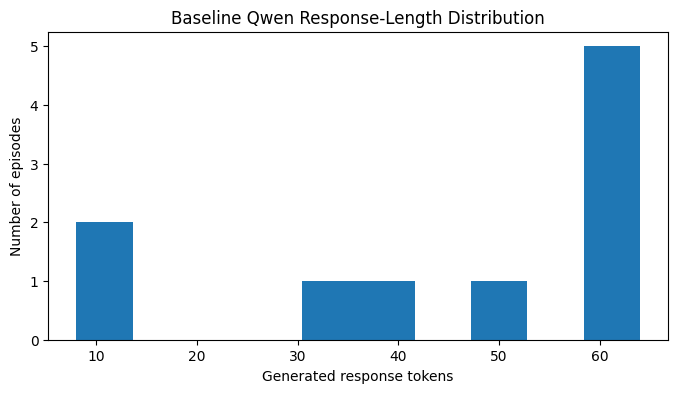

In [27]:
plt.figure(figsize=(8, 4))

plt.hist(
    metrics_df["response_tokens"],
    bins=min(10, len(metrics_df)),
)

plt.xlabel("Generated response tokens")
plt.ylabel("Number of episodes")
plt.title("Baseline Qwen Response-Length Distribution")

plt.show()

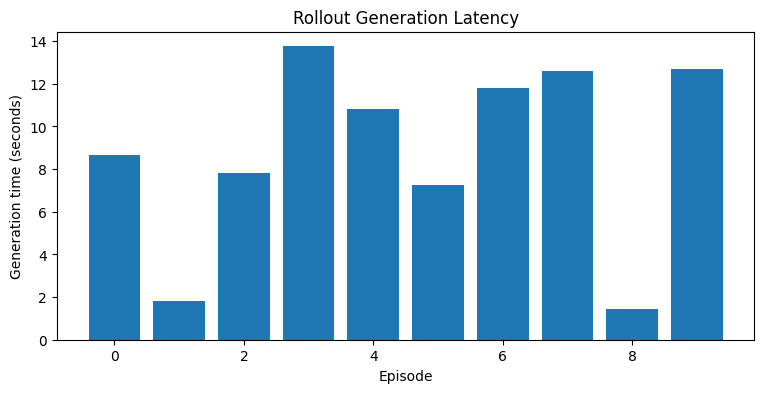

In [28]:
plt.figure(figsize=(9, 4))

plt.bar(
    metrics_df["episode"],
    metrics_df["generation_time_sec"],
)

plt.xlabel("Episode")
plt.ylabel("Generation time (seconds)")
plt.title("Rollout Generation Latency")

plt.show()

### Visualize Where Actions Occur

Let's create one compact visualization of the trajectory mask.

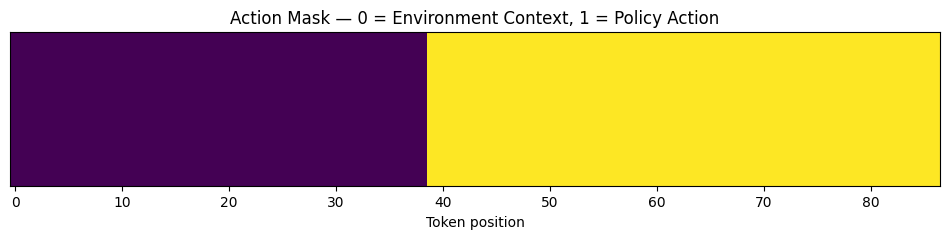

In [29]:
example = eval_trajectories[0]

mask_values = example.action_mask[0].int().numpy()

plt.figure(figsize=(12, 2))

plt.imshow(
    mask_values.reshape(1, -1),
    aspect="auto",
)

plt.yticks([])
plt.xlabel("Token position")
plt.title(
    "Action Mask — 0 = Environment Context, 1 = Policy Action"
)

plt.show()

In [31]:
def print_gpu_memory():
    if not torch.cuda.is_available():
        print("CUDA GPU not available.")
        return

    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    max_allocated = torch.cuda.max_memory_allocated() / 1024**3

    print(f"Allocated VRAM     : {allocated:.3f} GB")
    print(f"Reserved VRAM      : {reserved:.3f} GB")
    print(f"Peak allocated VRAM: {max_allocated:.3f} GB")


print_gpu_memory()

Allocated VRAM     : 2.884 GB
Reserved VRAM      : 3.086 GB
Peak allocated VRAM: 2.895 GB


In [33]:
for trajectory_i in eval_trajectories:
    validate_trajectory(trajectory_i)

assert len(eval_trajectories) == len(eval_prompts)

assert all(
    t.prompt_length > 0
    for t in eval_trajectories
)

assert all(
    t.response_length > 0
    for t in eval_trajectories
)

assert all(
    t.input_ids.shape == t.attention_mask.shape
    for t in eval_trajectories
)

assert all(
    t.input_ids.shape == t.action_mask.shape
    for t in eval_trajectories
)


All trajectory checks passed.
All trajectory checks passed.
All trajectory checks passed.
All trajectory checks passed.
All trajectory checks passed.
All trajectory checks passed.
All trajectory checks passed.
All trajectory checks passed.
All trajectory checks passed.
All trajectory checks passed.


## Summary: Complete Rollout Pipeline

```text
Qwen 1.5B Policy
        │
        ▼
Chat Template
        │
        ▼
Environment Context
        │
        ▼
Autoregressive Sampling
        │
        ▼
Policy Actions
        │
        ├── prompt/response separation
        ├── action mask
        ├── attention mask
        ├── EOS detection
        ├── truncation detection
        │
        ▼
LLMTrajectory
        │
        ├── token-level inspection
        ├── validation assertions
        ├── sequence alignment inspection
        │
        ▼
Rollout Evaluation
        ├── response length
        ├── EOS rate
        ├── truncation rate
        ├── latency
        ├── throughput
        └── GPU memory
```

## Key Takeaway

And most importantly, you can now concretely interpret generation as:

$$s_t = (x, y_{<t})$$

$$a_t = y_t$$

$$\pi_\theta(a_t | s_t) = P_\theta(y_t | x, y_{<t})$$

Your Qwen model isn't merely "generating text" anymore.

It's a **stochastic policy** producing an **RL trajectory** one token at a time.